<a href="https://colab.research.google.com/github/asommula-code/PRODIGY_ML_03/blob/main/PRODIGY_ML_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
uploaded = files.upload()

Saving task3.zip to task3 (1).zip


In [ ]:
import zipfile
import os

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Extracted successfully")


print("Contents of /content/dataset:")

for root, dirs, filenames in os.walk("/content/dataset"):
    level = root.replace("/content/dataset", '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in filenames:
        print(f'{subindent}{f}')

Extracted successfully
Contents of /content/dataset:
dataset/
    task3/
        Dog/
            1.jpg
            4.jpg
            9.jpg
            5.jpg
            6.jpg
            7.jpg
            3.jpg
            2.jpg
            0.jpg
            10.jpg
            8.jpg
        Cat/
            1.jpg
            4.jpg
            9.jpg
            5.jpg
            6.jpg
            7.jpg
            3.jpg
            2.jpg
            0.jpg
            10.jpg
            8.jpg


In [ ]:
dataset_path = "/content/dataset"

categories = ["cat", "dog"]
IMG_SIZE = 128

In [ ]:
data = []
labels = []

for category in categories:

    folder = os.path.join(dataset_path, "task3", category.capitalize())

    for img_name in os.listdir(folder):
        try:
            img_path = os.path.join(folder, img_name)

            img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
            img = tf.keras.utils.img_to_array(img) / 255.0

            data.append(img)
            labels.append(category)

        except Exception as e:
            # Print the error for debugging, instead of just passing silently
            print(f"Error loading image {img_path}: {e}")

data = np.array(data)
labels = np.array(labels)

print("Dataset loaded:", data.shape)

Dataset loaded: (22, 128, 128, 3)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(labels)

print("Classes:", list(le.classes_))

Classes: [np.str_('cat'), np.str_('dog')]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data, y, test_size=0.2, random_state=42
)

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=16
)

Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.3529 - loss: 0.9985 - val_accuracy: 1.0000 - val_loss: 0.2430
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 1.0000 - loss: 0.1967 - val_accuracy: 1.0000 - val_loss: 0.1061
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 1.0000 - loss: 0.0941 - val_accuracy: 1.0000 - val_loss: 0.0710
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 1.0000 - loss: 0.0344 - val_accuracy: 1.0000 - val_loss: 0.0878
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 1.0000 - loss: 0.0231 - val_accuracy: 1.0000 - val_loss: 0.1017


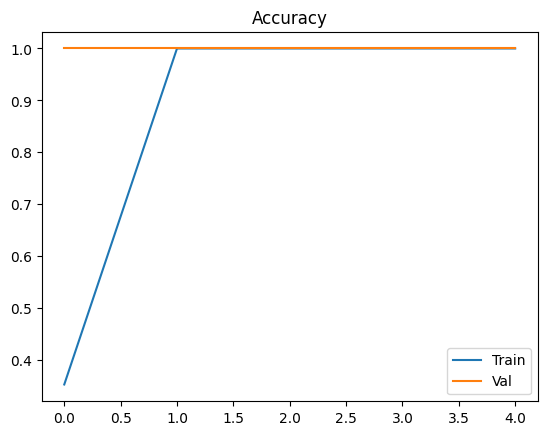

In [ ]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend()
plt.title("Accuracy")
plt.show()

In [ ]:
uploaded = files.upload()

Saving 4.jpg to 4.jpg


In [ ]:
def predict(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(128,128))
    img = tf.keras.utils.img_to_array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)[0][0]

    return "Dog" if pred > 0.5 else "Cat"

In [ ]:
for file in uploaded.keys():
    print(file)
    print("Prediction:", predict(file))

4.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: Dog


Saving 4.jpg to 4 (1).jpg

File selected: 4 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Prediction: Dog


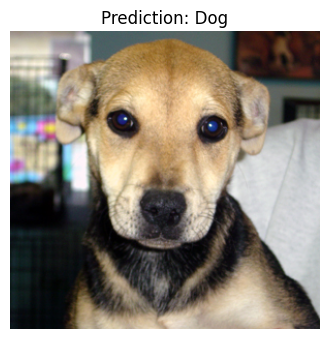

In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
import cv2

uploaded = files.upload()

def predict(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(128,128))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)[0][0]

    if pred > 0.5:
        return "Dog"
    else:
        return "Cat"

for file_name in uploaded.keys():
    print("\nFile selected:", file_name)


    result = predict(file_name)
    print("Prediction:", result)

    img = cv2.imread(file_name)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"Prediction: {result}")
    plt.axis("off")
    plt.show()

Saving 3.jpg to 3 (1).jpg

File selected: 3 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Prediction: Cat


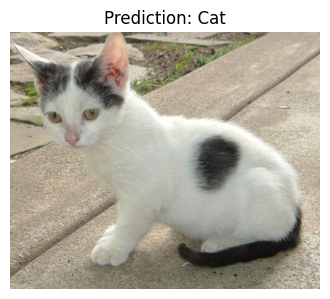

In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
import cv2

uploaded = files.upload()

def predict(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(128,128))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)[0][0]

    if pred > 0.5:
        return "Dog"
    else:
        return "Cat"

for file_name in uploaded.keys():
    print("\nFile selected:", file_name)

    result = predict(file_name)
    print("Prediction:", result)

    img = cv2.imread(file_name)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"Prediction: {result}")
    plt.axis("off")
    plt.show()